## More plotting

- Descriptive statistics
- Other statistical plots

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
x, y = np.loadtxt('../data/data.txt', unpack=True)

[[69.30830304  1.9505702 ]
 [50.76032587  1.96861572]
 [62.85323761  1.34300807]
 [70.68897252  1.6022082 ]
 [78.55575649  1.51523175]]


## Scatter plots

Useful to get a sense of the data and their relationship

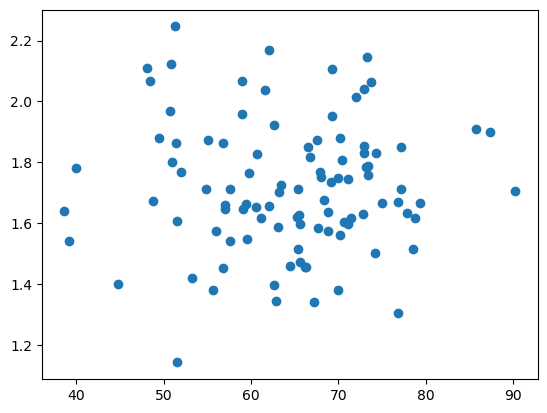

In [10]:
plt.scatter(x, y);

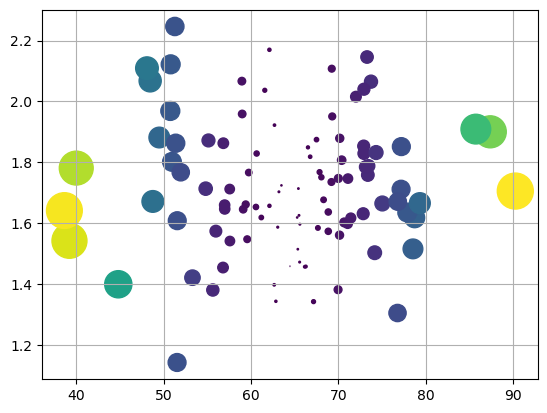

In [9]:
# Can also show size and color.
# We construct a simple scalar to display.
s  = (x-np.mean(x))**2 + (y - np.mean(y))**2
plt.scatter(x, y, c=s, s=s)
plt.grid();

## Histograms

Very useful to get a sense of the distribution of the data.

(array([ 1.,  3., 10.,  9., 26., 19., 16.,  5.,  8.,  3.]),
 array([1.14193387, 1.25235794, 1.36278201, 1.47320608, 1.58363015,
        1.69405422, 1.80447828, 1.91490235, 2.02532642, 2.13575049,
        2.24617456]),
 <BarContainer object of 10 artists>)

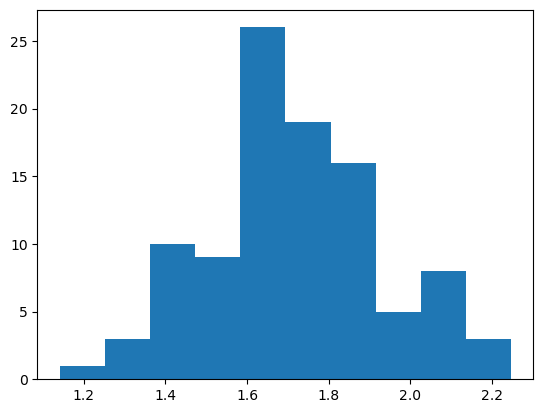

In [20]:
plt.hist(y)

(array([0.00522758, 0.00871263, 0.0209103 , 0.02962293, 0.03485051,
        0.04182061, 0.02613788, 0.00174253, 0.00522758]),
 array([38.62946704, 44.36826437, 50.10706171, 55.84585904, 61.58465637,
        67.32345371, 73.06225104, 78.80104838, 84.53984571, 90.27864304]),
 <BarContainer object of 9 artists>)

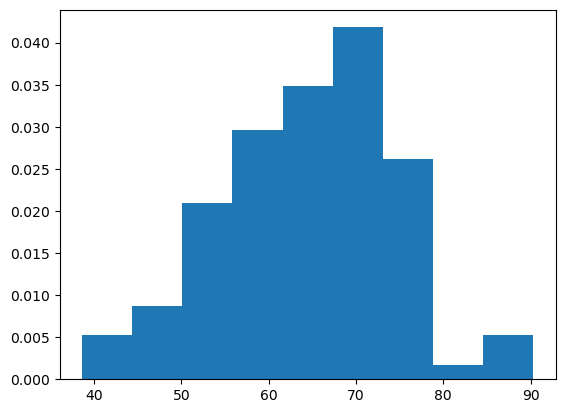

In [22]:
# Warning default bins are just 10, using 'auto' is always a better idea.
plt.hist(x, bins='auto', density=True)

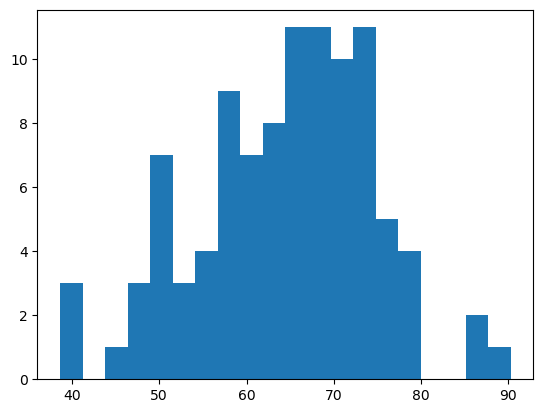

In [13]:
# But if you know better you can specify the number of bins.
plt.hist(x, bins=20);

Note the output of this is the counts, bins_edges, patches

[ 3.  5. 12. 17. 20. 24. 15.  1.  3.] [38.62946704 44.36826437 50.10706171 55.84585904 61.58465637 67.32345371
 73.06225104 78.80104838 84.53984571 90.27864304]


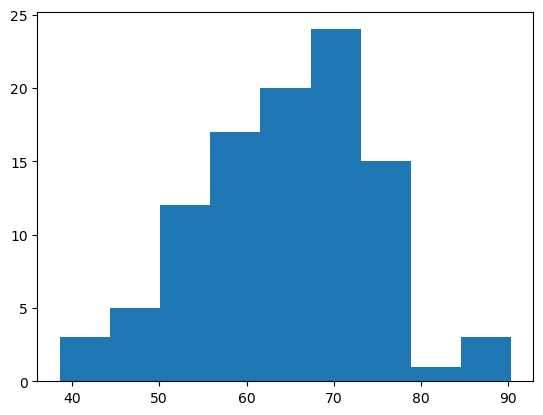

In [20]:
counts, bins, patches = plt.hist(x, bins='auto');
print(counts,bins)

[ 3  5 12 17 20 24 15  1  3] [38.62946704 44.36826437 50.10706171 55.84585904 61.58465637 67.32345371
 73.06225104 78.80104838 84.53984571 90.27864304]
[0.00522758 0.00871263 0.0209103  0.02962293 0.03485051 0.04182061
 0.02613788 0.00174253 0.00522758] [38.62946704 44.36826437 50.10706171 55.84585904 61.58465637 67.32345371
 73.06225104 78.80104838 84.53984571 90.27864304]
[0.00522758 0.00871263 0.0209103  0.02962293 0.03485051 0.04182061
 0.02613788 0.00174253 0.00522758] [38.62946704 44.36826437 50.10706171 55.84585904 61.58465637 67.32345371
 73.06225104 78.80104838 84.53984571 90.27864304]


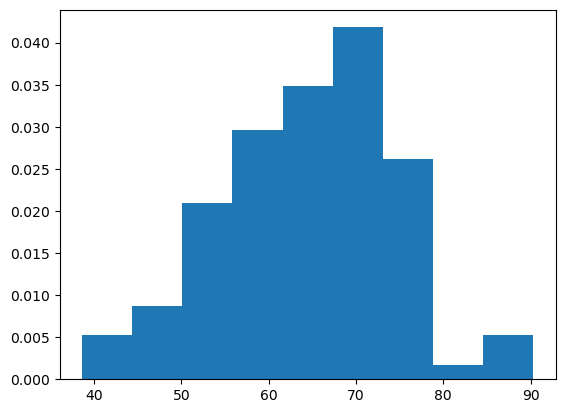

In [ ]:
# Numpy is used to generate the counts, bins
c, b = np.histogram(x, bins='auto')
print(c,b)
c, b = np.histogram(x, bins='auto', density=True)
print(c,b)
c, b, patches = plt.hist(x, bins='auto', density=True)
print(c,b)

### Cumulative and relative histograms

- Hope you've seen this in your Statistics course?
- You get an empirical probability density function (PDF) through a
  histogram!
- But this has to be a relative histogram, i.e. use `density=True`
- A cumulative histogram is an approximation to a Cumulative Distribution
  Function (CDF)

This is very important and valuable as we will see later.

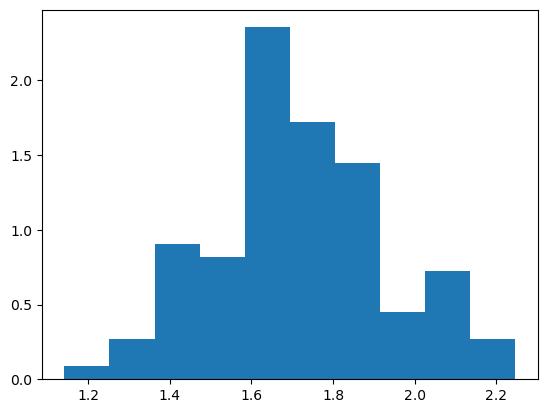

In [21]:
# Relative histogram.
plt.hist(y, bins='auto', density=True);

(array([0.01, 0.04, 0.14, 0.23, 0.49, 0.68, 0.84, 0.89, 0.97, 1.  ]),
 array([1.14193387, 1.25235794, 1.36278201, 1.47320608, 1.58363015,
        1.69405422, 1.80447828, 1.91490235, 2.02532642, 2.13575049,
        2.24617456]),
 <BarContainer object of 10 artists>)

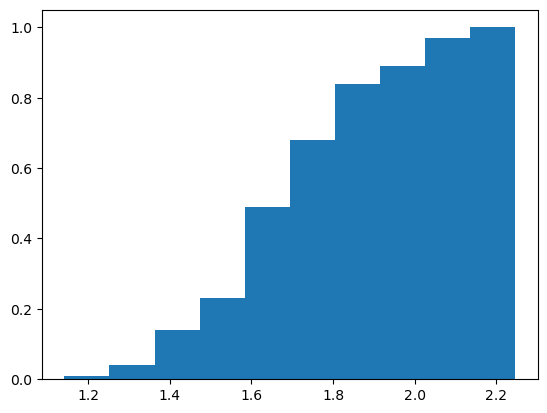

In [27]:
plt.hist(y, bins='auto', cumulative=True, density=True)

## Box-plots

- Powerful plotting utility
- Shows the distribution of the data at a glance
- Typically shows the following:
   - Median, Q1, Q3, IQR
   - Q1 - 1.5 x IQR, Q3 + 1.5 x IQR


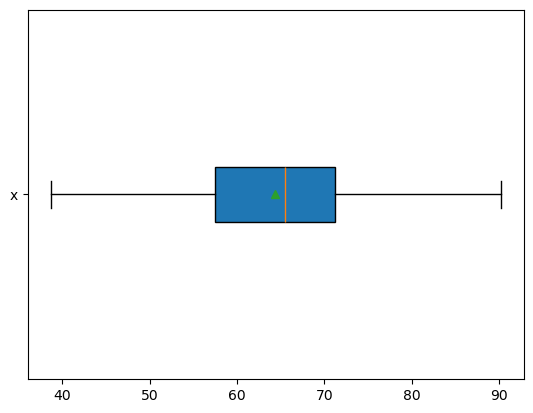

In [28]:
plt.boxplot(x, tick_labels=['x'], showmeans=True, orientation='horizontal', patch_artist=True);

- Can show multiple boxplots together


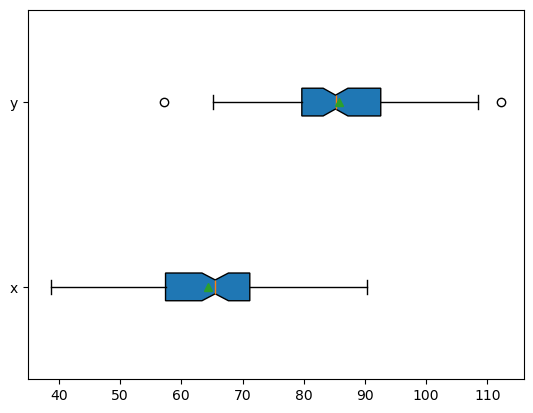

In [30]:
plt.boxplot((x, y*50), tick_labels=['x', 'y'], showmeans=True, patch_artist=True,notch=True, orientation='horizontal');

## Violin plots!

- Combine PDFs and box plots.


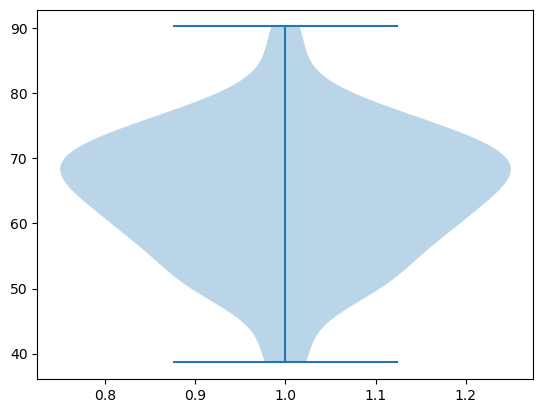

In [28]:
plt.violinplot(x);

In [ ]:
plt.violinplot(y);

## Pearson's correlation coefficient

 $$\begin{aligned}
 r = \frac{\sum_i (x_i - \bar{x}) (y_i - \bar{y})}{(n-1) s_x s_y} \\
 \end{aligned}$$$$r = \frac{\sum_i (x_i - \bar{x}) (y_i - \bar{y}) }
          {\sqrt {\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

- $-1 \leq r \leq 1$
- \"Small\" r implies lower correlation

In [31]:
np.corrcoef(x, y)

array([[1.        , 0.00618002],
       [0.00618002, 1.        ]])

## Pie and bar charts.

- In general avoid pie charts, use barcharts/histograms instead.
- But here is how you can do this.

Consider this data:

| **Cancer**  | Lung | Breast | Colon | Prostate | Melanoma | Bladder |
|-------------|------|--------|-------|----------|----------|---------|
| **Numbers** | 42   |  50    |  32   |   55     |  9       |  12     |


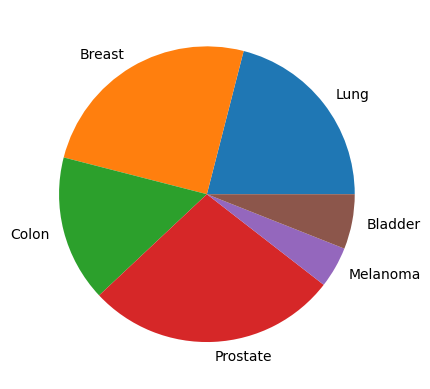

In [31]:
# Solution
cancer = ['Lung', 'Breast', 'Colon', 'Prostate', 'Melanoma', 'Bladder']
numbers = [42, 50, 32, 55, 9, 12]
plt.pie(numbers, labels=cancer, shadow=False);

### Better to use a bar chart


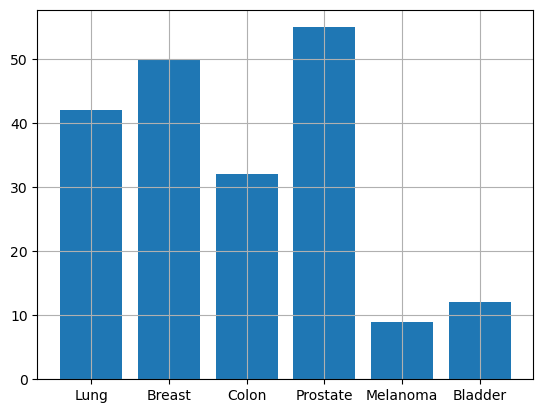

In [32]:
x = np.arange(len(numbers))
plt.bar(x, numbers, tick_label=cancer)
plt.grid();

## Exercise

- Load the data in `'sachin.txt'`, and `'kohli.txt'`
- These have the ODI runs for Sachin Tendulkar and Virat Kohli
- They have a single column each
- Load the data using `np.loadtxt`
- Show a histogram (relative) for each.
- Show them together, use the same approach as we did for boxplot.
- Hint: use `plt.legend` to set the legend
- Show the data using a boxplot
- Show the data using a violin plot.

Comment on the player's performance

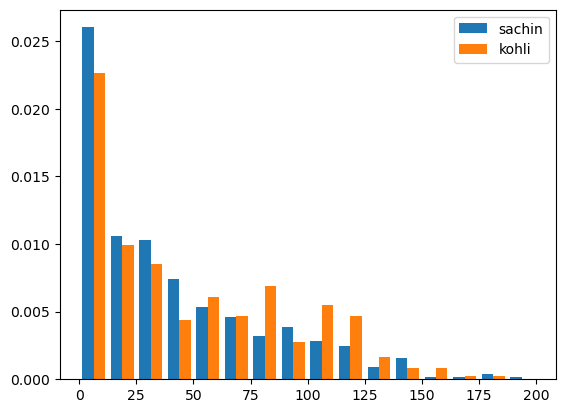

In [38]:
# Solution
sachin = np.loadtxt('../data/sachin.txt')
kohli = np.loadtxt('../data/kohli.txt')
plt.hist((sachin, kohli), bins='auto', density=True);
plt.legend(['sachin','kohli'])

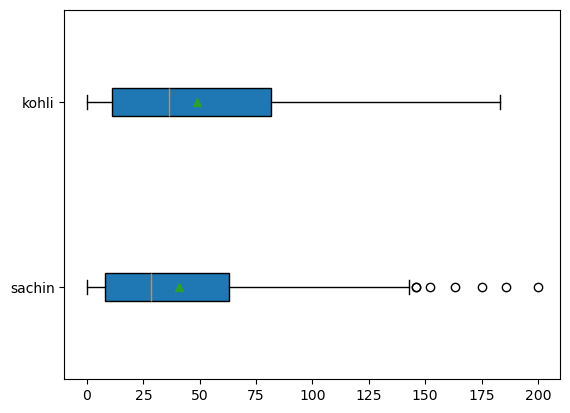

In [40]:
plt.boxplot((sachin,kohli), tick_labels=['sachin','kohli'], showmeans=True, orientation='horizontal', patch_artist=True);

## Connection to probability theory

- We've seen various kinds of plots
- So far this is entirely visual
- We can actually do very powerful things with this

Let us first look at how histograms work.

- Counts number of occurrences in each bin.
- Bins are chosen automatically via `'auto'` or explicitly specified

### Probability mass function (PMF)

- Used for discrete distributions, Bernoulli, Binomial, Poisson etc.
- Assigns probability for each value $p(x)$
- Empirically, this is basically the relative count of occurrence of the
  value! Note that this is exactly how a relative histogram is found.

### Probability density function (PDF)

- Used for continuous distributions, uniform, normal, Chi-square, T etc.
- Probability density function: $f(x)$
- Probability in some region of $x$, $\Delta x$ is: $f(x) \Delta x$

In this case, for N data points, the values of the histogram are = `count/(N*bin_width)`
This produces the density function.

Consider Sachin's scores

In [41]:
ds = np.loadtxt('../data/sachin.txt')
print(len(ds), max(ds))

452 200.0


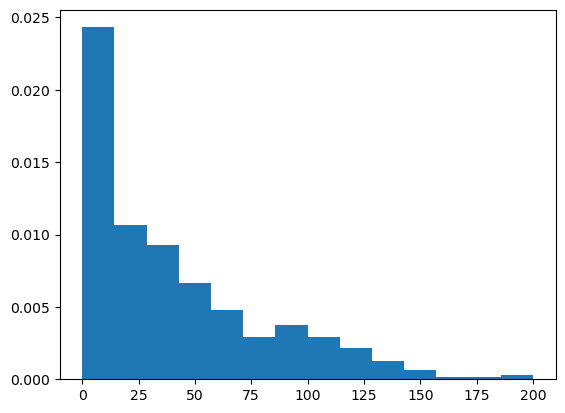

In [42]:
# A simple histogram is not enough
plt.hist(ds, bins='auto', density=True);

- The problem with this is that this is not really a probability mass
  function.
- It is a PDF.

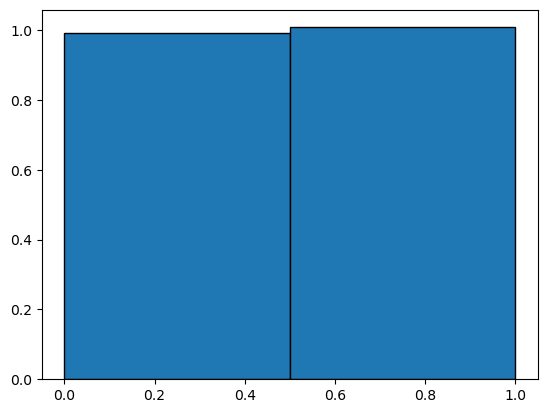

In [43]:
c, b, p = plt.hist(np.random.randint(0, 2, size=10000), bins=2, density=True, edgecolor='black');

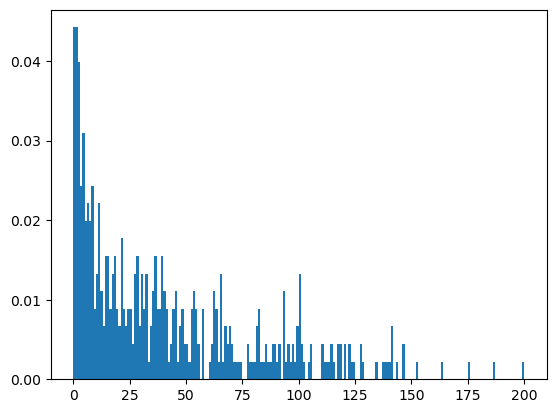

In [36]:
# This will produce a rough PMF
plt.hist(ds, bins=range(201), density=True);


This is not perfect since we have only about 450 points in total (which is
quite a bit).

If all we want is the counts without a plot, we can simply use `np.histogram`

In [44]:
pmf, bins = np.histogram(ds, bins=range(201), density=True)
print(pmf,bins)

[0.04424779 0.04424779 0.03982301 0.02433628 0.03097345 0.0199115
 0.02212389 0.0199115  0.02433628 0.00884956 0.01327434 0.02212389
 0.01106195 0.00663717 0.01548673 0.01548673 0.00884956 0.01327434
 0.01548673 0.00884956 0.00663717 0.01769912 0.00884956 0.00663717
 0.00884956 0.00884956 0.00442478 0.01327434 0.01548673 0.00663717
 0.01327434 0.00884956 0.01327434 0.00221239 0.00663717 0.01106195
 0.01548673 0.00884956 0.00884956 0.01548673 0.01106195 0.00884956
 0.00221239 0.00442478 0.00884956 0.01106195 0.00221239 0.00663717
 0.00884956 0.00442478 0.00442478 0.00221239 0.00884956 0.01106195
 0.00884956 0.00442478 0.         0.00884956 0.         0.
 0.00221239 0.00442478 0.01106195 0.00884956 0.00221239 0.01327434
 0.00221239 0.00663717 0.00442478 0.00663717 0.00442478 0.00221239
 0.00221239 0.00221239 0.00221239 0.         0.         0.00442478
 0.00221239 0.00221239 0.00221239 0.00663717 0.00884956 0.00221239
 0.00221239 0.00442478 0.00221239 0.00221239 0.00442478 0.00442478
 0.0

### Why is this useful

If you know the PMF/PDF you basically know a great deal about the data.
You can use it to ask all sorts of probability based questions.

- What is the median score, what is the IQR, etc.?
- What is the probability that Sachin will score < 10?
- What is the probability that he will score > 50?
- What is the probability that he will score > 100 given that he crossed 50?

These are quite deep questions that can be easily answered with the data.
You can do this to even compare players.

## Exercise

Try to answer some of these quickly.

1. What is the probability that Sachin will score < 10?
2. What is the probability that Sachin will score > 50?
3. What is the probability that he will cross 100 given that he crossed 50?

We can do this either with a PMF or a PDF.

<BarContainer object of 200 artists>


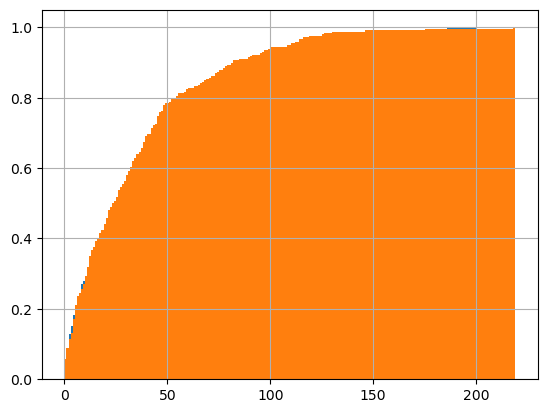

In [46]:
rohit = np.loadtxt('../data/rohit.txt')
gambhir =np.loadtxt('../data/gambhir.txt')
kohli = np.loadtxt('../data/kohli.txt')
sachin = np.loadtxt('../data/sachin.txt')
sehwag = np.loadtxt('../data/sehwag.txt')

sachinCDF, bins_sachin, p = plt.hist(sachin, bins=range(int(max(sachin)) + 1), density=True, cumulative=True);
print(p)
sehwagCDF, bins_sehwag, p = plt.hist(sehwag, bins=range(int(max(sehwag)) + 1), density=True, cumulative=True);
plt.grid();

In [66]:
print(sachinCDF)

[0.04424779 0.08849558 0.12831858 0.15265487 0.18362832 0.20353982
 0.22566372 0.24557522 0.2699115  0.27876106 0.2920354  0.31415929
 0.32522124 0.33185841 0.34734513 0.36283186 0.37168142 0.38495575
 0.40044248 0.40929204 0.4159292  0.43362832 0.44247788 0.44911504
 0.4579646  0.46681416 0.47123894 0.48451327 0.5        0.50663717
 0.5199115  0.52876106 0.5420354  0.54424779 0.55088496 0.5619469
 0.57743363 0.58628319 0.59513274 0.61061947 0.62168142 0.63053097
 0.63274336 0.63716814 0.6460177  0.65707965 0.65929204 0.6659292
 0.67477876 0.67920354 0.68362832 0.68584071 0.69469027 0.70575221
 0.71460177 0.71902655 0.71902655 0.72787611 0.72787611 0.72787611
 0.7300885  0.73451327 0.74557522 0.75442478 0.75663717 0.7699115
 0.77212389 0.77876106 0.78318584 0.78982301 0.79424779 0.79646018
 0.79867257 0.80088496 0.80309735 0.80309735 0.80309735 0.80752212
 0.80973451 0.8119469  0.81415929 0.82079646 0.82964602 0.83185841
 0.8340708  0.83849558 0.84070796 0.84292035 0.84734513 0.8517699

In [43]:
# Q1. What is the probability that Sachin will score < 10
# Note that the bins start at 0 and include the left limit of each bin.
print(b[9], c[9])  # So the c[9] value gives the sum of all probabilities < 10

9.0 0.2787610619469027


In [57]:
# Q2. What is the probability that Sachin will score > 50?
print("Answer:", 1 - sachinCDF[50])  # 1-c[50] is probability that Sachin scores > 50.
print("Answer:", 1 - sehwagCDF[50])  

Answer: 0.3163716814159292
Answer: 0.21632653061224483


In [48]:
# Q3. What is the probability that he will score > 100 (event A) given that he crossed 50 (event B)?
# Sachin has already crossed 50 and the chances of that is the answer to problem Q2, i.e. 1-c[50]
# event A can happen only when event B has happened so $P(A \cap B) = P(A)$, furthermore, $P(A | B) = P(A \cap B)/P(B)$ so:
print((1- sehwagCDF[100])/(1 - sehwagCDF[50]))
print((1- sachinCDF[100])/(1 - sachinCDF[50]))

0.2641509433962204
0.3006993006993042


In [65]:
# Note on how the CDF is made.
c, b = np.histogram(ds, bins=range(201), density=True)
counts = np.cumsum(c)  # This is your CDF.
print(counts)

[0.04424779 0.08849558 0.12831858 0.15265487 0.18362832 0.20353982
 0.22566372 0.24557522 0.2699115  0.27876106 0.2920354  0.31415929
 0.32522124 0.33185841 0.34734513 0.36283186 0.37168142 0.38495575
 0.40044248 0.40929204 0.4159292  0.43362832 0.44247788 0.44911504
 0.4579646  0.46681416 0.47123894 0.48451327 0.5        0.50663717
 0.5199115  0.52876106 0.5420354  0.54424779 0.55088496 0.5619469
 0.57743363 0.58628319 0.59513274 0.61061947 0.62168142 0.63053097
 0.63274336 0.63716814 0.6460177  0.65707965 0.65929204 0.6659292
 0.67477876 0.67920354 0.68362832 0.68584071 0.69469027 0.70575221
 0.71460177 0.71902655 0.71902655 0.72787611 0.72787611 0.72787611
 0.7300885  0.73451327 0.74557522 0.75442478 0.75663717 0.7699115
 0.77212389 0.77876106 0.78318584 0.78982301 0.79424779 0.79646018
 0.79867257 0.80088496 0.80309735 0.80309735 0.80309735 0.80752212
 0.80973451 0.8119469  0.81415929 0.82079646 0.82964602 0.83185841
 0.8340708  0.83849558 0.84070796 0.84292035 0.84734513 0.8517699


As you can see, the PDF/PMF is incredibly useful when answering practical
questions.

We will upload an exercise for you to do based on these.
